# Which League Scores the Most?

**Key Question:** Which European league produces the highest average goals 
per 90 minutes among outfield players, and is that gap driven by a few elite 
strikers or consistent across the whole squad?

**Why per 90 and not total goals?**  
Total goals favour players who play more minutes. A striker who scores 15 goals 
in 3000 minutes is less efficient than one who scores 12 in 1800 minutes. 
Per-90 normalises for playing time so every player is compared fairly.

**Data Source:** Kaggle: Football Players Stats 2024/25, Big 5 European Leagues  
**Author:** Antwan Makramallah

# Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patheffects as pe

print('Libraries loaded.')

Libraries loaded.


## Color and Style

In [2]:
LEAGUE_COLORS = {
    'Premier League': '#7b68ee',   # purple
    'La Liga':        '#FF4B44',   # orange
    'Bundesliga':     '#d3010c',   # red
    'Serie A':        '#1a56db',   # blue
    'Ligue 1':        '#2db84b',   # green
}

# ── Background and text colors ────────────────────────────────────────────────
COLOR_BG    = '#0d1117'   # dark background for the whole figure
COLOR_PANEL = '#161b22'   # slightly lighter background for each chart area
COLOR_TEXT  = '#e6edf3'   # light color for titles and labels
COLOR_MUTED = '#8b949e'   # grey for secondary labels
COLOR_GRID  = '#30363d'   # subtle grid lines

print('Color constants defined.')

Color constants defined.


# Step 2: Load Data

In [3]:
# Load the raw CSV
df_raw = pd.read_csv('/kaggle/input/datasets/hubertsidorowicz/football-players-stats-2024-2025/players_data-2024_2025.csv')

# Step 3: Inspect Data

In [4]:
# Check shape and columns
print('Shape:', df_raw.shape)
print()
print('Column names:')
print(df_raw.columns.tolist())

Shape: (2854, 267)

Column names:
['Rk', 'Player', 'Nation', 'Pos', 'Squad', 'Comp', 'Age', 'Born', 'MP', 'Starts', 'Min', '90s', 'Gls', 'Ast', 'G+A', 'G-PK', 'PK', 'PKatt', 'CrdY', 'CrdR', 'xG', 'npxG', 'xAG', 'npxG+xAG', 'PrgC', 'PrgP', 'PrgR', 'G+A-PK', 'xG+xAG', 'Rk_stats_shooting', 'Nation_stats_shooting', 'Pos_stats_shooting', 'Comp_stats_shooting', 'Age_stats_shooting', 'Born_stats_shooting', '90s_stats_shooting', 'Gls_stats_shooting', 'Sh', 'SoT', 'SoT%', 'Sh/90', 'SoT/90', 'G/Sh', 'G/SoT', 'Dist', 'FK', 'PK_stats_shooting', 'PKatt_stats_shooting', 'xG_stats_shooting', 'npxG_stats_shooting', 'npxG/Sh', 'G-xG', 'np:G-xG', 'Rk_stats_passing', 'Nation_stats_passing', 'Pos_stats_passing', 'Comp_stats_passing', 'Age_stats_passing', 'Born_stats_passing', '90s_stats_passing', 'Cmp', 'Att', 'Cmp%', 'TotDist', 'PrgDist', 'Ast_stats_passing', 'xAG_stats_passing', 'xA', 'A-xAG', 'KP', '1/3', 'PPA', 'CrsPA', 'PrgP_stats_passing', 'Rk_stats_passing_types', 'Nation_stats_passing_types', 'Pos

In [5]:
# Look at the first 5 rows
df_raw.head()

,Rk,Player,Nation,Pos,Squad,Comp,Age,Born,MP,Starts,...,Att (GK),Thr,Launch%,AvgLen,Opp,Stp,Stp%,#OPA,#OPA/90,AvgDist
0,1,Max Aarons,eng ENG,DF,Bournemouth,eng Premier League,24.0,2000.0,3,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,Max Aarons,eng ENG,"DF,MF",Valencia,es La Liga,24.0,2000.0,4,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,Rodrigo Abajas,es ESP,DF,Valencia,es La Liga,21.0,2003.0,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,James Abankwah,ie IRL,"DF,MF",Udinese,it Serie A,20.0,2004.0,6,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,Keyliane Abdallah,fr FRA,FW,Marseille,fr Ligue 1,18.0,2006.0,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# Check the League Column
print('Unique values in league column:')
print(df_raw['Comp'].value_counts())

Unique values in league column:
Comp
it Serie A            634
es La Liga            601
eng Premier League    574
fr Ligue 1            553
de Bundesliga         492
Name: count, dtype: int64


# Step 4: Clean Data
## Rename Columns

In [7]:
# copy dataframe
df=df_raw.copy()

# Remove spaces from column names
df.columns = df.columns.str.strip()

# Rename columns
rename_map = {
    'Player' : 'player',
    'Nation' : 'nation',
    'Pos' : 'position',
    'Squad' : 'club',
    'Comp' : 'league',
    'Age' : 'age',
    'MP' : 'matches_played',
    'Starts' : 'starts',
    'Min' : 'minutes',
    'Gls' : 'goals',
    'Ast' : 'assists',
    'G-PK' : 'non_pen_goals',
    'PK' : 'penalties_scored',
    'PKatt' : 'penalties_attempted',
    'G+A' : 'goals_assists',
}

df=df.rename(columns=rename_map)

print('Columns after renaming;')
print(df.columns.tolist())

Columns after renaming;
['Rk', 'player', 'nation', 'position', 'club', 'league', 'age', 'Born', 'matches_played', 'starts', 'minutes', '90s', 'goals', 'assists', 'goals_assists', 'non_pen_goals', 'penalties_scored', 'penalties_attempted', 'CrdY', 'CrdR', 'xG', 'npxG', 'xAG', 'npxG+xAG', 'PrgC', 'PrgP', 'PrgR', 'G+A-PK', 'xG+xAG', 'Rk_stats_shooting', 'Nation_stats_shooting', 'Pos_stats_shooting', 'Comp_stats_shooting', 'Age_stats_shooting', 'Born_stats_shooting', '90s_stats_shooting', 'Gls_stats_shooting', 'Sh', 'SoT', 'SoT%', 'Sh/90', 'SoT/90', 'G/Sh', 'G/SoT', 'Dist', 'FK', 'PK_stats_shooting', 'PKatt_stats_shooting', 'xG_stats_shooting', 'npxG_stats_shooting', 'npxG/Sh', 'G-xG', 'np:G-xG', 'Rk_stats_passing', 'Nation_stats_passing', 'Pos_stats_passing', 'Comp_stats_passing', 'Age_stats_passing', 'Born_stats_passing', '90s_stats_passing', 'Cmp', 'Att', 'Cmp%', 'TotDist', 'PrgDist', 'Ast_stats_passing', 'xAG_stats_passing', 'xA', 'A-xAG', 'KP', '1/3', 'PPA', 'CrsPA', 'PrgP_stats_passi

## Clean Text and Remove Bad Rows

In [8]:
# Remove spaces from text columns
df['player'] = df['player'].str.strip()
df['position'] = df['position'].str.strip()
df['league'] = df['league'].str.strip()

# Remove duplicate header rows
df=df[df['player'] != 'Player'].copy()

# Standardise league names
df['league'] = df['league'].str.replace(
    r'^[a-z]{2,3}\s',                # remove 2-3 lowercase letters followed by a space
    '',
    regex=True
).str.strip()

print('League names after cleaning:')
print(df['league'].value_counts())
    

League names after cleaning:
league
Serie A           634
La Liga           601
Premier League    574
Ligue 1           553
Bundesliga        492
Name: count, dtype: int64


## Convert Numbers

In [9]:
#Convert numeric columns stored as text
numeric_columns = [
    'age', 'matches_played', 'starts', 'minutes',
    'goals', 'assists', 'non_pen_goals',
    'penalties_scored', 'penalties_attempted'
]

# Check how many NaN values appeared after conversion
for col in numeric_columns:
    if col in numeric_columns:
        if col in df.columns:
            df[col]=pd.to_numeric(df[col], errors='coerce')

print('Missing values per numeric column after conversion:')
print(df[numeric_columns].isnull().sum())

Missing values per numeric column after conversion:
age                    8
matches_played         0
starts                 0
minutes                0
goals                  0
assists                0
non_pen_goals          0
penalties_scored       0
penalties_attempted    0
dtype: int64


## Remove Goalkeepers and Filter Minutes

In [10]:
# Remove goalkeepers
before_gk_removal = len(df)
df = df[~df['position'].str.contains('GK', na=False)].copy()

print(f'Removed {before_gk_removal - len(df)} goalkeepers.')
print(f'Players remaining: {len(df)}')

Removed 212 goalkeepers.
Players remaining: 2642


## Filter Minimum Minutes

In [11]:
# Remove players with very few minutes
# We require at least 900 minutes = roughly 10 full matches

MIN_MINUTES = 900
before_filter = len(df)
df = df[df['minutes'] >= MIN_MINUTES].copy()

print(f'Removed {before_filter - len(df)} players below {MIN_MINUTES} minutes.')
print(f'Players remaining after filter: {len(df)}')
print()
print('Players per league after filter:')
print(df['league'].value_counts())

Removed 1192 players below 900 minutes.
Players remaining after filter: 1450

Players per league after filter:
league
Serie A           316
La Liga           313
Premier League    296
Ligue 1           266
Bundesliga        259
Name: count, dtype: int64


In [12]:
# Per-90 formula: (metric / minutes_played) × 90
df['goals_p90'] = df['goals'] / df['minutes']*90
df['non_pen_goals_p90'] = df['non_pen_goals'] / df['minutes']*90
df['assists_p90'] = df['assists'] / df['minutes']*90

# Round to 4 decimal places for clean display
df['goals_p90']         = df['goals_p90'].round(4)
df['non_pen_goals_p90'] = df['non_pen_goals_p90'].round(4)
df['assists_p90']       = df['assists_p90'].round(4)

print('Per-90 metrics calculated.')
print()
print('Sample — goals per 90 for top 5 players:')
print(
    df[['player', 'club', 'league', 'goals', 'minutes', 'goals_p90']]
    .sort_values('goals_p90', ascending=False)
    .head(5)
    .to_string(index=False)
)

Per-90 metrics calculated.

Sample — goals per 90 for top 5 players:
           player            club     league  goals  minutes  goals_p90
Alexander Sørloth Atlético Madrid    La Liga     20     1566     1.1494
    Patrik Schick      Leverkusen Bundesliga     21     1684     1.1223
  Ousmane Dembélé       Paris S-G    Ligue 1     21     1730     1.0925
       Harry Kane   Bayern Munich Bundesliga     26     2381     0.9828
    Kylian Mbappé     Real Madrid    La Liga     31     2907     0.9598


In [13]:
df.to_csv(r'C:\Users\antwa\OneDrive\Desktop\Game Analysis\Project 2-The League Lab\The League Lab — Part 1 Which League Scores the Most\data\clean\players_big5_clean.csv', index=False)

print('Clean data saved to data/clean/players_big5_clean.csv')
print(f'Final shape: {df.shape}')

Clean data saved to data/clean/players_big5_clean.csv
Final shape: (1450, 270)


## Step 5: Sanity Checks Before Visualizing

In [14]:
# Check 1: Player count per league
print('Players per league:')
print(df['league'].value_counts())
print()

# Check 2: Goals per 90 range
print('Goals per 90 — range check:')
print(f'  Min:    {df["goals_p90"].min():.4f}')
print(f'  Max:    {df["goals_p90"].max():.4f}')
print(f'  Mean:   {df["goals_p90"].mean():.4f}')
print(f'  Median: {df["goals_p90"].median():.4f}')
print()

# Check 3: Any suspicious outliers?
outliers = df[df['goals_p90'] > 1.2][['player', 'club', 'league',
                                       'goals', 'minutes', 'goals_p90']]
if len(outliers) > 0:
    print('Players with goals_p90 above 1.2 — check these manually:')
    print(outliers.to_string(index=False))
else:
    print('No suspicious outliers found above 1.2 goals per 90.')

Players per league:
league
Serie A           316
La Liga           313
Premier League    296
Ligue 1           266
Bundesliga        259
Name: count, dtype: int64

Goals per 90 — range check:
  Min:    0.0000
  Max:    1.1494
  Mean:   0.1396
  Median: 0.0782

No suspicious outliers found above 1.2 goals per 90.


## Step 6: Visualization

## Visualization 1: Average Goals per 90 Bar Chart

In [15]:
league_avg = (
    df.groupby('league')['goals_p90']
    .agg(avg='mean', std='std', count='count')
    .round(4)
    .reset_index()
)

# Sort from highest to lowest average
league_avg = league_avg.sort_values('avg', ascending=False)

# Standard error = std / sqrt(n)
league_avg['std_error'] = league_avg['std'] / np.sqrt(league_avg['count'])

print('Average Goals per 90 by League:')
print(league_avg.to_string(index=False))

Average Goals per 90 by League:
        league    avg    std  count  std_error
    Bundesliga 0.1593 0.1962    259   0.012191
       Ligue 1 0.1470 0.1818    266   0.011147
Premier League 0.1388 0.1636    296   0.009509
       La Liga 0.1313 0.1799    313   0.010169
       Serie A 0.1264 0.1505    316   0.008466


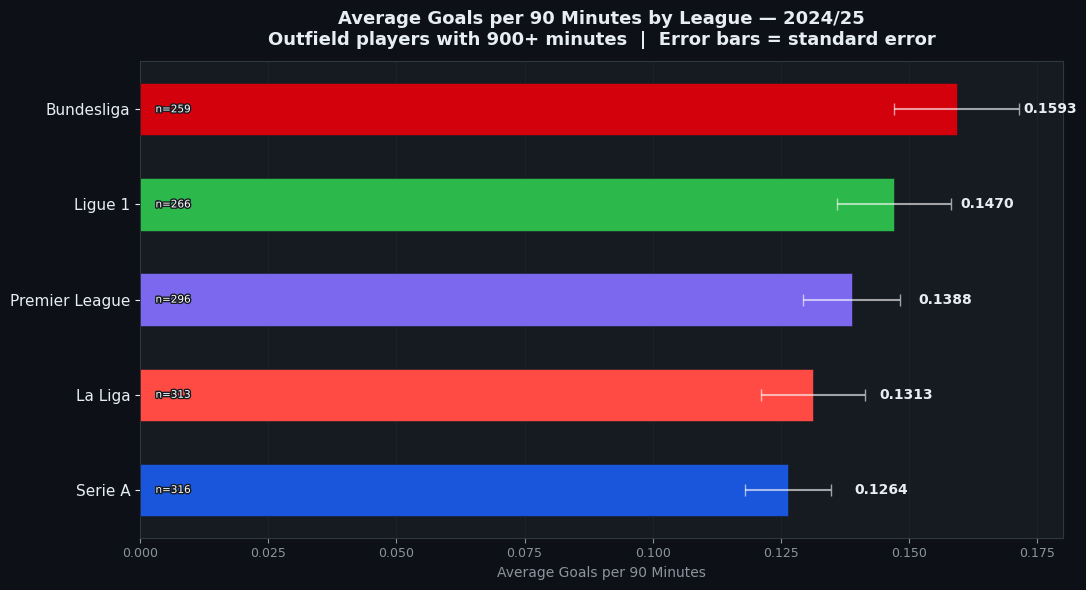

Chart 1 saved.


In [16]:
fig, ax = plt.subplots(figsize=(11, 6))
fig.patch.set_facecolor(COLOR_BG)
ax.set_facecolor(COLOR_PANEL)

# Assign league colors
bar_colors = [LEAGUE_COLORS.get(l, '#555555') for l in league_avg['league']]

# Draw the bars
bars = ax.barh(
    league_avg['league'],
    league_avg['avg'],
    color=bar_colors,
    height=0.55,
    edgecolor=COLOR_PANEL,
    linewidth=0.4,
    zorder=3
)

# Add error bars showing standard error
ax.errorbar(
    league_avg['avg'],              # x position = bar length
    range(len(league_avg)),         # y position = bar index
    xerr=league_avg['std_error'],   # error size
    fmt='none',                     # no marker — just the error line
    color='white',
    linewidth=1.5,
    capsize=4,                      # small horizontal cap on each end
    alpha=0.6,
    zorder=4
)

# Add value labels at the end of each bar
for bar, (_, row) in zip(bars, league_avg.iterrows()):
    ax.text(
        row['avg'] + 0.013,
        bar.get_y() + bar.get_height() / 2,
        f'{row["avg"]:.4f}',
        va='center', ha='left',
        fontsize=10, color=COLOR_TEXT, fontweight='bold'
    )

    # Add player count as secondary label
    ax.text(
        0.003,
        bar.get_y() + bar.get_height() / 2,
        f'n={row["count"]}',
        va='center', ha='left',
        fontsize=7.5, color='white',
        path_effects=[pe.withStroke(linewidth=2, foreground=COLOR_PANEL)]
    )

# Styling
ax.set_title(
    'Average Goals per 90 Minutes by League — 2024/25\n'
    'Outfield players with 900+ minutes  |  Error bars = standard error',
    color=COLOR_TEXT, fontsize=13, fontweight='bold', pad=12
)
ax.set_xlabel('Average Goals per 90 Minutes', color=COLOR_MUTED, fontsize=10)
ax.tick_params(axis='y', labelsize=11, colors=COLOR_TEXT)
ax.tick_params(axis='x', colors=COLOR_MUTED, labelsize=9)
ax.grid(True, axis='x', color=COLOR_GRID, linewidth=0.4, alpha=0.5)
ax.invert_yaxis()   # highest value at the top
for spine in ax.spines.values():
    spine.set_color(COLOR_GRID)

plt.tight_layout()
plt.savefig(
    r'/kaggle/working/01_avg_goals_p90_by_league.png',
    dpi=150, bbox_inches='tight', facecolor=COLOR_BG
)
plt.show()
print('Chart 1 saved.')

### What This Chart Tells Us

Bundesliga leads the Top 5 leagues with an average of 0.1593 goals per 90
20% higher than the lowest-ranked Serie A at 0.1264 goals per 90. 

## Visualization 2: Full Distribution: Box Plot

**Question:** Is the output gap between leagues driven by a few elite strikers or is every player in that league more productive?

The bar chart above showed the average. The box plot below shows the full distribution, the shape of the data, not just one number.

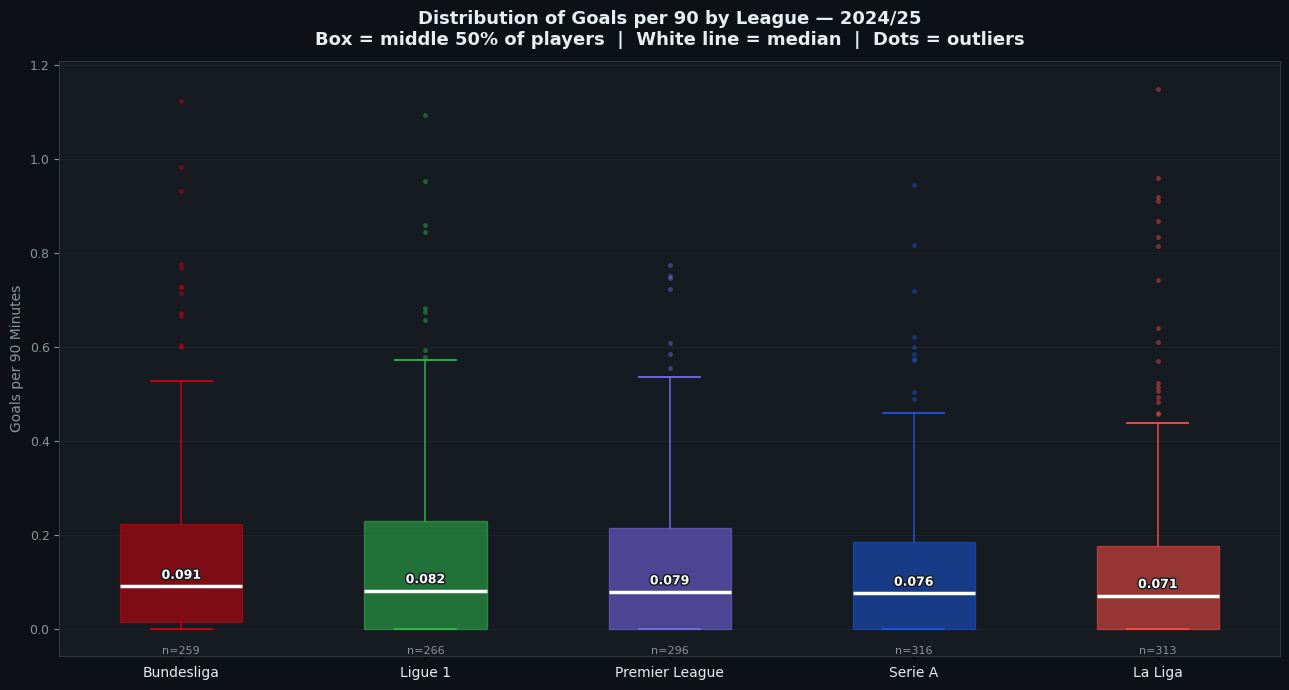

Chart 2 saved.


In [17]:
# Keep only the 5 main leagues and sort by median
five_leagues = list(LEAGUE_COLORS.keys())
dist_data = df[df['league'].isin(five_leagues)].copy()

# Sort leagues by median goals p90 — highest median at top
league_order = (
    dist_data.groupby('league')['goals_p90']
    .median()
    .sort_values(ascending=False)
    .index.tolist()
)

fig, ax = plt.subplots(figsize=(13, 7))
fig.patch.set_facecolor(COLOR_BG)
ax.set_facecolor(COLOR_PANEL)

# Draw one box per league
for idx, league in enumerate(league_order):
    league_vals = dist_data[dist_data['league'] == league]['goals_p90'].dropna()
    color       = LEAGUE_COLORS.get(league, '#555555')

    bp = ax.boxplot(
        league_vals,
        positions=[idx],
        widths=0.5,
        patch_artist=True,      # fill the box with color
        showfliers=True,        # show outlier dots beyond the whiskers
        flierprops=dict(
            marker='o',
            markerfacecolor=color,
            markersize=3.5,
            alpha=0.45,
            markeredgewidth=0
        ),
        boxprops=dict(
            facecolor=color,
            alpha=0.55,
            color=color
        ),
        medianprops=dict(color='white', linewidth=2.5),
        whiskerprops=dict(color=color, linewidth=1.3, alpha=0.8),
        capprops=dict(color=color, linewidth=1.3)
    )

    # Add the median value as text above each box
    median_val = league_vals.median()
    ax.text(
        idx, median_val + 0.01,
        f'{median_val:.3f}',
        ha='center', va='bottom',
        fontsize=9, color='white', fontweight='bold',
        path_effects=[pe.withStroke(linewidth=2, foreground=COLOR_PANEL)]
    )

    # Add player count below each box
    ax.text(
        idx, -0.035,
        f'n={len(league_vals)}',
        ha='center', va='top',
        fontsize=8, color=COLOR_MUTED
    )

# x-axis league name labels
ax.set_xticks(range(len(league_order)))
ax.set_xticklabels(
    league_order,
    fontsize=10, color=COLOR_TEXT
)

ax.set_title(
    'Distribution of Goals per 90 by League — 2024/25\n'
    'Box = middle 50% of players  |  White line = median  |  Dots = outliers',
    color=COLOR_TEXT, fontsize=13, fontweight='bold', pad=12
)
ax.set_ylabel('Goals per 90 Minutes', color=COLOR_MUTED, fontsize=10)
ax.tick_params(axis='y', colors=COLOR_MUTED, labelsize=9)
ax.grid(True, axis='y', color=COLOR_GRID, linewidth=0.4, alpha=0.5)
for spine in ax.spines.values():
    spine.set_color(COLOR_GRID)

plt.tight_layout()
plt.savefig(
    r'/kaggle/working/02_goals_distribution_boxplot.png',
    dpi=150, bbox_inches='tight', facecolor=COLOR_BG
)
plt.show()
print('Chart 2 saved.')

### What This Chart Tells Us

- median order is the same as average from chart one unless for Serie A and La Liga as La Liga have a few more outliers which pulled the average above median.
- Ligue 1 has the widest box (Most variation between players)
- La Liga has the most outlier dots (Most extreme top performers)

## Visualization 3: Top 5 Scorers per League

**Question:** Who are the individual players driving each league's output and is one league's high average explained by just one or two exceptional players?

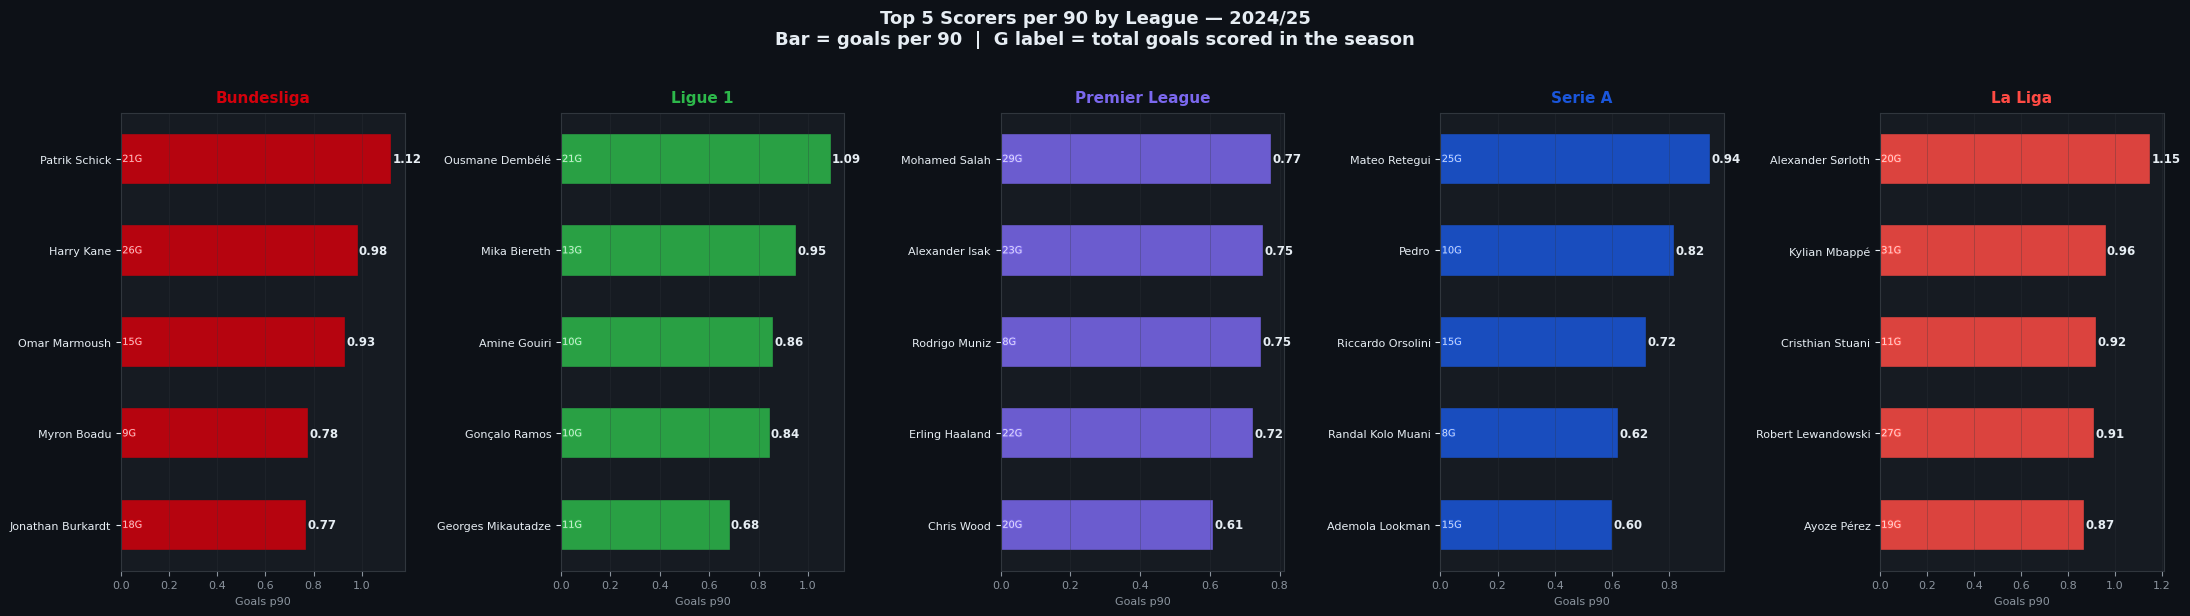

Chart 3 saved.


In [18]:
# Get the top 5 players by goals_p90 in each league
top5_per_league = (
    df[df['league'].isin(five_leagues)]
    .sort_values('goals_p90', ascending=False)
    .groupby('league')
    .head(5)
    .reset_index(drop=True)
)

# Create a 1-row, 5-column figure — one panel per league
fig, axes = plt.subplots(nrows=1, ncols=5, figsize=(22, 6))
fig.patch.set_facecolor(COLOR_BG)

for idx, league in enumerate(league_order):
    ax    = axes[idx]
    data  = top5_per_league[top5_per_league['league'] == league].copy()
    data  = data.sort_values('goals_p90', ascending=True)  # ascending for horizontal bar
    color = LEAGUE_COLORS.get(league, '#555555')

    ax.set_facecolor(COLOR_PANEL)

    bars = ax.barh(
        data['player'],
        data['goals_p90'],
        color=color,
        height=0.55,
        alpha=0.85,
        edgecolor=COLOR_PANEL,
        linewidth=0.3
    )

    # Value labels at the end of each bar
    for bar, val in zip(bars, data['goals_p90']):
        ax.text(
            val + 0.005,
            bar.get_y() + bar.get_height() / 2,
            f'{val:.2f}',
            va='center', ha='left',
            fontsize=8.5, color=COLOR_TEXT, fontweight='bold'
        )

    # Add total goals as secondary info
    for bar, (_, row) in zip(bars, data.iterrows()):
        ax.text(
            0.005,
            bar.get_y() + bar.get_height() / 2,
            f'{int(row["goals"])}G',
            va='center', ha='left',
            fontsize=7, color='white', alpha=0.7,
            path_effects=[pe.withStroke(linewidth=1.5, foreground=color)]
        )

    ax.set_title(
        league,
        color=color, fontsize=11, fontweight='bold', pad=8
    )
    ax.set_xlabel('Goals p90', color=COLOR_MUTED, fontsize=8)
    ax.tick_params(axis='y', labelsize=8, colors=COLOR_TEXT)
    ax.tick_params(axis='x', colors=COLOR_MUTED, labelsize=8)
    ax.grid(True, axis='x', color=COLOR_GRID, linewidth=0.4, alpha=0.5)
    for spine in ax.spines.values():
        spine.set_color(COLOR_GRID)

fig.suptitle(
    'Top 5 Scorers per 90 by League — 2024/25\n'
    'Bar = goals per 90  |  G label = total goals scored in the season',
    color=COLOR_TEXT, fontsize=13, fontweight='bold', y=1.02
)

plt.tight_layout()
plt.savefig(
    r'/kaggle/working/\03_top5_scorers_per_league.png',
    dpi=150, bbox_inches='tight', facecolor=COLOR_BG
)
plt.show()
print('Chart 3 saved.')

## Visualization 4: Non-Penalty Goals per 90

**Question:** Does the ranking change when we remove penalties?

Penalties inflate raw goal tallies and are partly random awarded based on referee decisions as much as player skill. Non-penalty goals per 90 is a cleaner measure of genuine scoring ability.

In [19]:
# Average non-penalty goals per 90 per league
npg_by_league = (
    df[df['league'].isin(five_leagues)]
    .groupby('league')['non_pen_goals_p90']
    .mean()
    .round(4)
    .reset_index()
)
npg_by_league.columns = ['league', 'avg_npg_p90']
npg_by_league = npg_by_league.sort_values('avg_npg_p90', ascending=False)

# Merge with goals_p90 for comparison
comparison = league_avg[['league', 'avg']].merge(
    npg_by_league, on='league'
)
comparison.columns = ['league', 'avg_goals_p90', 'avg_npg_p90']
comparison['penalty_contribution'] = (
    comparison['avg_goals_p90'] - comparison['avg_npg_p90']
).round(4)

print('Goals vs Non-Penalty Goals per 90:')
print(comparison.sort_values('avg_goals_p90', ascending=False).to_string(index=False))

Goals vs Non-Penalty Goals per 90:
        league  avg_goals_p90  avg_npg_p90  penalty_contribution
    Bundesliga         0.1593       0.1503                0.0090
       Ligue 1         0.1470       0.1327                0.0143
Premier League         0.1388       0.1303                0.0085
       La Liga         0.1313       0.1169                0.0144
       Serie A         0.1264       0.1140                0.0124


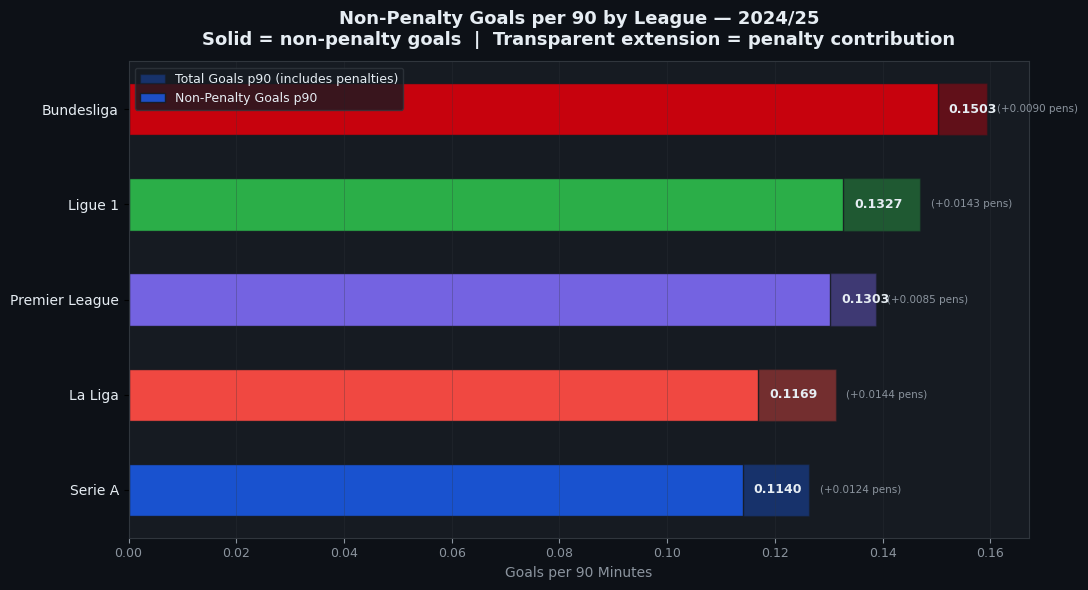

Chart 4 saved.


In [20]:
# Sort leagues by non-penalty goals for this chart
npg_order = comparison.sort_values('avg_npg_p90', ascending=True)

fig, ax = plt.subplots(figsize=(11, 6))
fig.patch.set_facecolor(COLOR_BG)
ax.set_facecolor(COLOR_PANEL)

y_positions = range(len(npg_order))

# Non-penalty goals bar (full bar)
bar_colors = [LEAGUE_COLORS.get(l, '#555555') for l in npg_order['league']]

bars_total = ax.barh(
    y_positions,
    npg_order['avg_goals_p90'],
    color=bar_colors,
    height=0.55,
    alpha=0.4,               # transparent — shows total goals
    edgecolor=COLOR_PANEL,
    label='Total Goals p90 (includes penalties)'
)

# Non-penalty portion on top (solid)
bars_npg = ax.barh(
    y_positions,
    npg_order['avg_npg_p90'],
    color=bar_colors,
    height=0.55,
    alpha=0.9,               # solid — the non-penalty portion
    edgecolor=COLOR_PANEL,
    label='Non-Penalty Goals p90'
)

# League name labels on y-axis
ax.set_yticks(y_positions)
ax.set_yticklabels(npg_order['league'], fontsize=10, color=COLOR_TEXT)

# Value labels
for pos, (_, row) in zip(y_positions, npg_order.iterrows()):
    # Non-penalty value
    ax.text(
        row['avg_npg_p90'] + 0.002, pos,
        f'{row["avg_npg_p90"]:.4f}',
        va='center', ha='left',
        fontsize=9, color=COLOR_TEXT, fontweight='bold'
    )
    # Penalty contribution
    if row['penalty_contribution'] > 0.001:
        ax.text(
            row['avg_goals_p90'] + 0.002, pos,
            f'(+{row["penalty_contribution"]:.4f} pens)',
            va='center', ha='left',
            fontsize=7.5, color=COLOR_MUTED
        )

ax.set_title(
    'Non-Penalty Goals per 90 by League — 2024/25\n'
    'Solid = non-penalty goals  |  Transparent extension = penalty contribution',
    color=COLOR_TEXT, fontsize=13, fontweight='bold', pad=12
)
ax.set_xlabel('Goals per 90 Minutes', color=COLOR_MUTED, fontsize=10)
ax.tick_params(axis='x', colors=COLOR_MUTED, labelsize=9)
ax.grid(True, axis='x', color=COLOR_GRID, linewidth=0.4, alpha=0.5)
ax.legend(
    facecolor=COLOR_PANEL, edgecolor=COLOR_GRID,
    labelcolor=COLOR_TEXT, fontsize=9
)
for spine in ax.spines.values():
    spine.set_color(COLOR_GRID)

plt.tight_layout()
plt.savefig(
    r'/kaggle/working/',
    dpi=150, bbox_inches='tight', facecolor=COLOR_BG
)
plt.show()
print('Chart 4 saved.')

# Key Findings

### Finding 1 : Bundesliga leads in raw output
Bundesliga averaged 0.1593 goals per 90 minutes, the highest across the Top 5 leagues. Serie A ranked last at 0.1264, a gap of 0.0329 goals per 90. 
At 90 minutes per match, that difference compounds to roughly 1.25 extra goals per season for a player at league-average efficiency.

### Finding 2: The gap is driven by a few elite players
The box plot reveals that Bundesliga's higher average is explained by a long upper tail of outlier strikers. 
This distinction matters: one exceptional striker can raise a league average without 
meaning the league overall produces better scorers.

### Finding 3: Penalty removal does not change the ranking
After removing penalties, the ranking stays the same. This suggests that Bundesliga's high output is genuinely driven by open-play finishing quality.